In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-05yhxlua
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-05yhxlua
  Resolved https://www.github.com/mouseland/cellpose.git to commit d95f58a6676362d4e625076e55cd73b47c3bae26
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'cellpose' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'cellpose'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for cellpose: filename=cellpose-4.0.7.dev14+gd95f58a66-py3-none-any.whl size=212496 sha256=7e58e00e96a7a7659489fb18a51f6e835c2fdf43f27af97df1ae1fb109979803
  S

In [ ]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup()

if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2025-09-18 16:04:47,576 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2025-09-18 16:04:47,577 [INFO] 
cellpose version: 	4.0.7.dev14+gd95f58a66 
platform:       	linux 
python version: 	3.12.11 
torch version:  	2.8.0+cu126
2025-09-18 16:04:48,025 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 16:04:48,027 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 16:04:48,028 [INFO] >>>> using GPU (CUDA)
2025-09-18 16:04:54,020 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:13<00:00, 91.9MB/s]


In [ ]:
img = io.imread('/content/test.jpeg')

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1066, 1600, 3). Assuming channel dimension is last with 3 channels


**FLOW_TH = 0.4** → threshold for flow field consistency (affects segmentation quality).

**CELLPROB_TH = 0.0** → threshold for cell probability (decides how aggressive detection is).

**TILE_NORM_BLOCKSIZE = 0** → disable tile-based normalization (set >0 to enable).

**MIN_SIZE = 25** → remove objects smaller than 25 px.

**MODEL_TYPE** = None → auto-select best model (cyto3, cyto2, cyto, nuclei).

**diameter** = None → Cellpose auto-estimates object size.

# **FUNCTION TO USE**

In [ ]:
# ===== Run best trials: cpsam_strict (RGB vs Grayscale) =====
import os, sys, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from imageio.v3 import imread
from cellpose import models, core, io, plot, utils
io.logger_setup()

# ---- Setup ----
IMG_PATH = "/content/test.jpeg"
FLOW_TH = 1.0          # strict
CELLPROB_TH = 0.1      # strict
TILE_NORM_BLOCKSIZE = 0
USE_GPU = True

if not core.use_gpu():
    raise RuntimeError("No GPU detected. In Colab: Runtime → Change runtime type → GPU.")

# ---- Load image ----
img = imread(IMG_PATH)
if img.ndim == 2:
    img = img[..., None]
elif img.ndim > 3:
    img = img[0]

print(f"Image shape: {img.shape}")

# ---- Convert to grayscale ----
def as_gray(img):
    if img.ndim == 2:
        return img[..., None]
    if img.shape[-1] == 1:
        return img
    r,g,b = img[...,0].astype(np.float32), img[...,1].astype(np.float32), img[...,2].astype(np.float32)
    y = 0.2126*r + 0.7152*g + 0.0722*b   # luminance conversion
    return y[..., None]

# ---- Helper: run one model + plot ----
def run_and_plot(model_type, img, flow_th, cellprob_th, force_gray=False):
    if force_gray:
        img_proc = as_gray(img)
        channels = (0,0)   # force grayscale channel use
        name = f"{model_type}_gray"
    else:
        img_proc = img
        channels = None if model_type == "cpsam" else (0,0)
        name = model_type

    print(f"\n=== Running {name} ===")
    model = models.CellposeModel(gpu=USE_GPU, model_type=model_type)

    out = model.eval(
        [img_proc],
        diameter=None,
        channels=channels,
        flow_threshold=flow_th,
        cellprob_threshold=cellprob_th,
        normalize={"tile_norm_blocksize": TILE_NORM_BLOCKSIZE},
        do_3D=False,
    )

    if len(out) == 4:
        masks, flows, styles, _ = out
    else:
        masks, flows, styles = out

    masks = masks[0].astype(np.int32)
    flows = flows[0]
    count = int(masks.max())
    print(f"{name} count: {count}")

    # ---- 4-panel visualization ----
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    # (1) Original
    axes[0,0].imshow(img if img.shape[-1]==1 else img[...,:3])
    axes[0,0].set_title("original image"); axes[0,0].axis("off")

    # (2) Outlines
    outlines = utils.outlines_list(masks)
    axes[0,1].imshow(img if img.shape[-1]==1 else img[...,:3])
    for o in outlines:
        axes[0,1].plot(o[:,0], o[:,1], color='red', linewidth=0.5)
    axes[0,1].set_title("predicted outlines"); axes[0,1].axis("off")

    # (3) Masks
    overlay = plot.mask_overlay(img, masks, colors=None)
    axes[1,0].imshow(overlay)
    axes[1,0].set_title("predicted masks"); axes[1,0].axis("off")

    # (4) Flows
    flow_rgb = plot.image_to_rgb(flows[0], channels=[0,0])
    axes[1,1].imshow(flow_rgb)
    axes[1,1].set_title("predicted cell pose"); axes[1,1].axis("off")

    plt.suptitle(f"Model: {name}", fontsize=14)
    plt.tight_layout()
    plt.show()




Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.12.11 
torch version:  	2.8.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


2025-09-18 17:41:12,217 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2025-09-18 17:41:12,218 [INFO] 
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.12.11 
torch version:  	2.8.0+cu126
2025-09-18 17:41:12,445 [INFO] ** TORCH CUDA version installed and working. **
Image shape: (1066, 1600, 3)


# Experiments

Available model_type options in v3.1.1

"cyto3" → improved cytoplasm model (v3)

"cyto2" → cytoplasm model (v2)

"cyto" → legacy cytoplasm model

"nuclei" → nuclei-only model

In [ ]:
! pip install cellpose==3.1.1

  Attempting uninstall: cellpose
    Found existing installation: cellpose 4.0.7.dev14+gd95f58a66
    Uninstalling cellpose-4.0.7.dev14+gd95f58a66:
      Successfully uninstalled cellpose-4.0.7.dev14+gd95f58a66



=== Running cyto3 ===


100%|██████████| 25.3M/25.3M [00:00<00:00, 30.7MB/s]


cyto3 count: 486


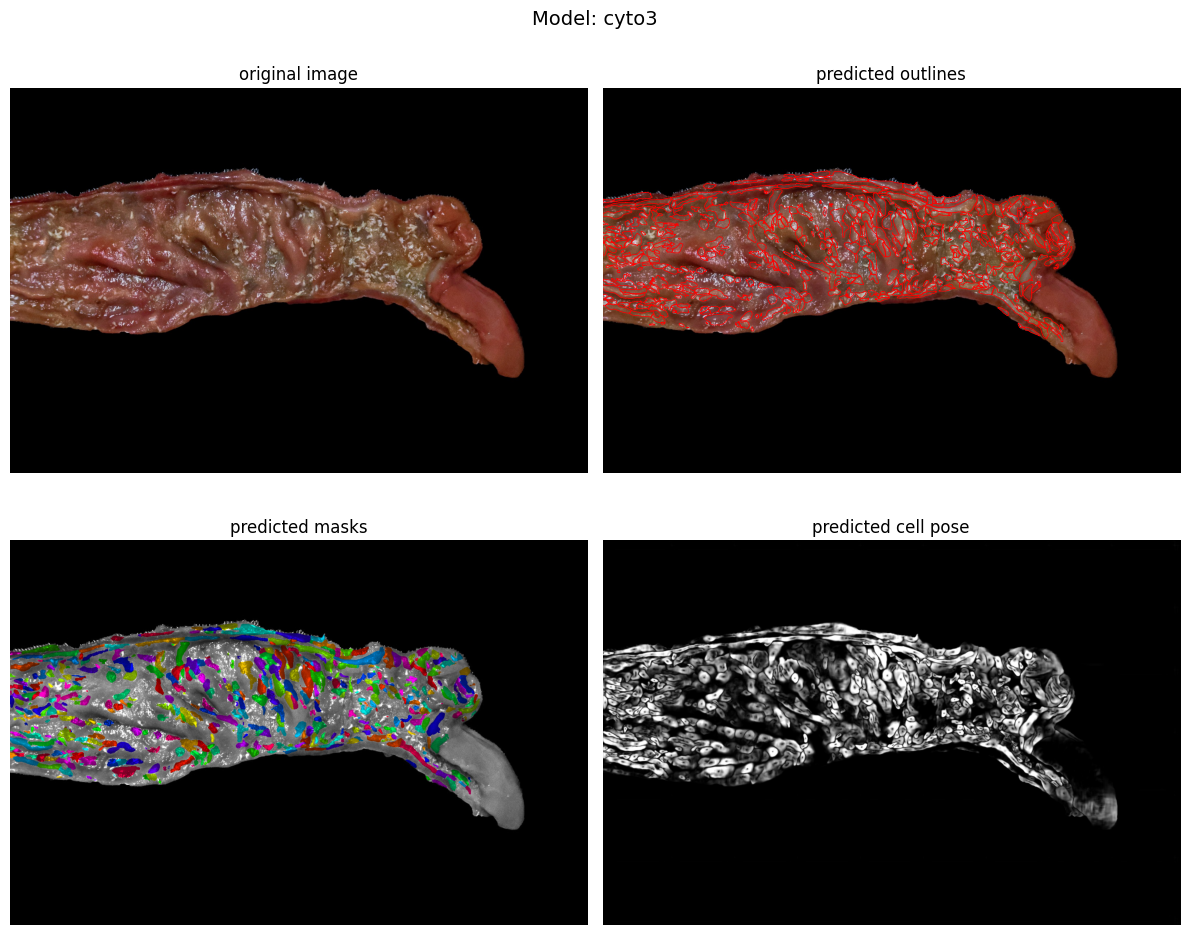

In [ ]:
# ---- Run both strict models ----
run_and_plot("cyto3", img, FLOW_TH, CELLPROB_TH)


upgrade (v4)

Available models: "cpsam", "omni".

In [ ]:
!pip install -U cellpose

  Using cached cellpose-4.0.6-py3-none-any.whl.metadata (22 kB)
Using cached cellpose-4.0.6-py3-none-any.whl (212 kB)
  Attempting uninstall: cellpose
    Found existing installation: cellpose 3.1.1
    Uninstalling cellpose-3.1.1:
      Successfully uninstalled cellpose-3.1.1



=== Running cpsam ===
2025-09-18 17:41:17,138 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:41:17,139 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:41:17,139 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:41:19,925 [INFO] >>>> loading model /root/.cellpose/models/cpsam
cpsam count: 306


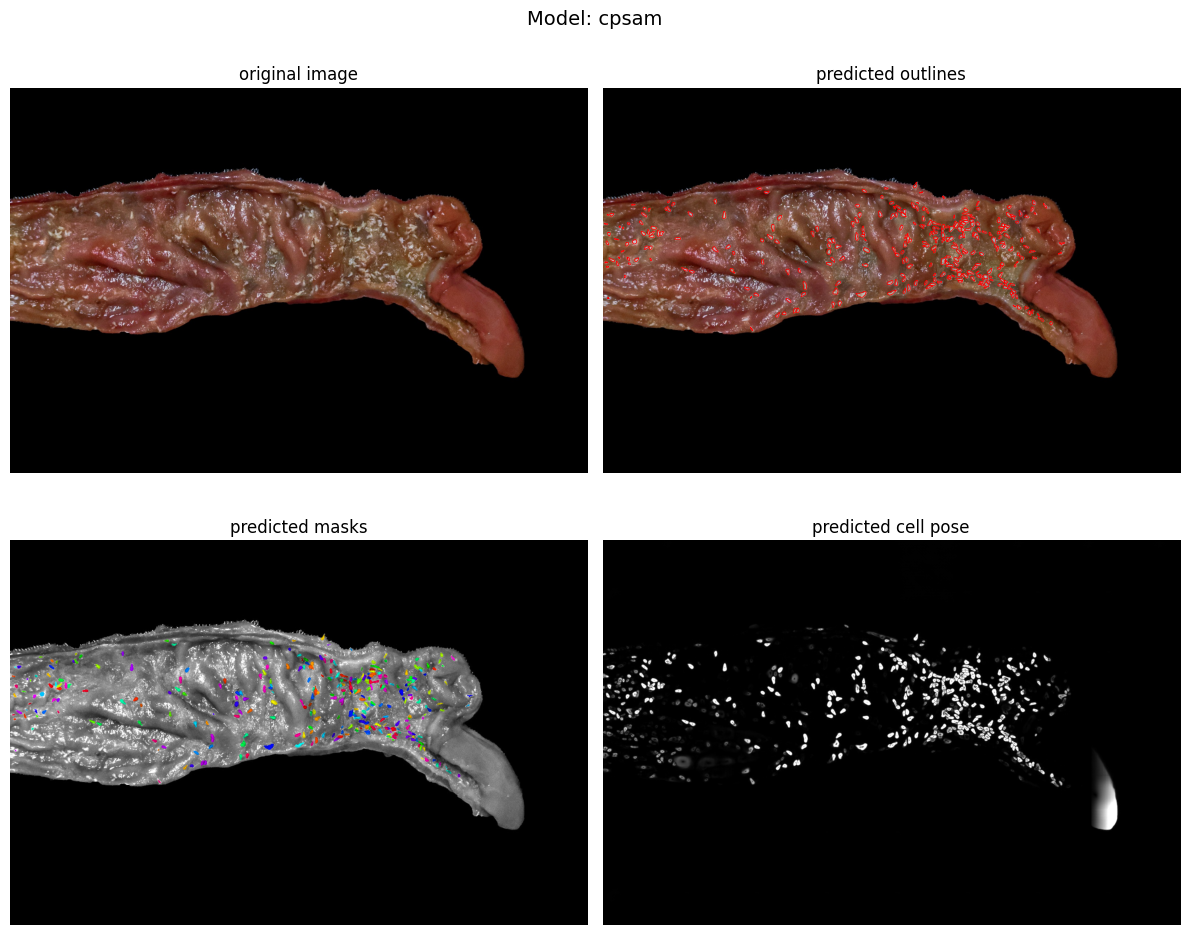

In [ ]:
run_and_plot("cpsam", img, FLOW_TH, CELLPROB_TH)


=== Running cpsam_gray ===
2025-09-18 17:42:20,924 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:42:20,925 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:42:20,927 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:42:24,585 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:42:25,128 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
cpsam_gray count: 340


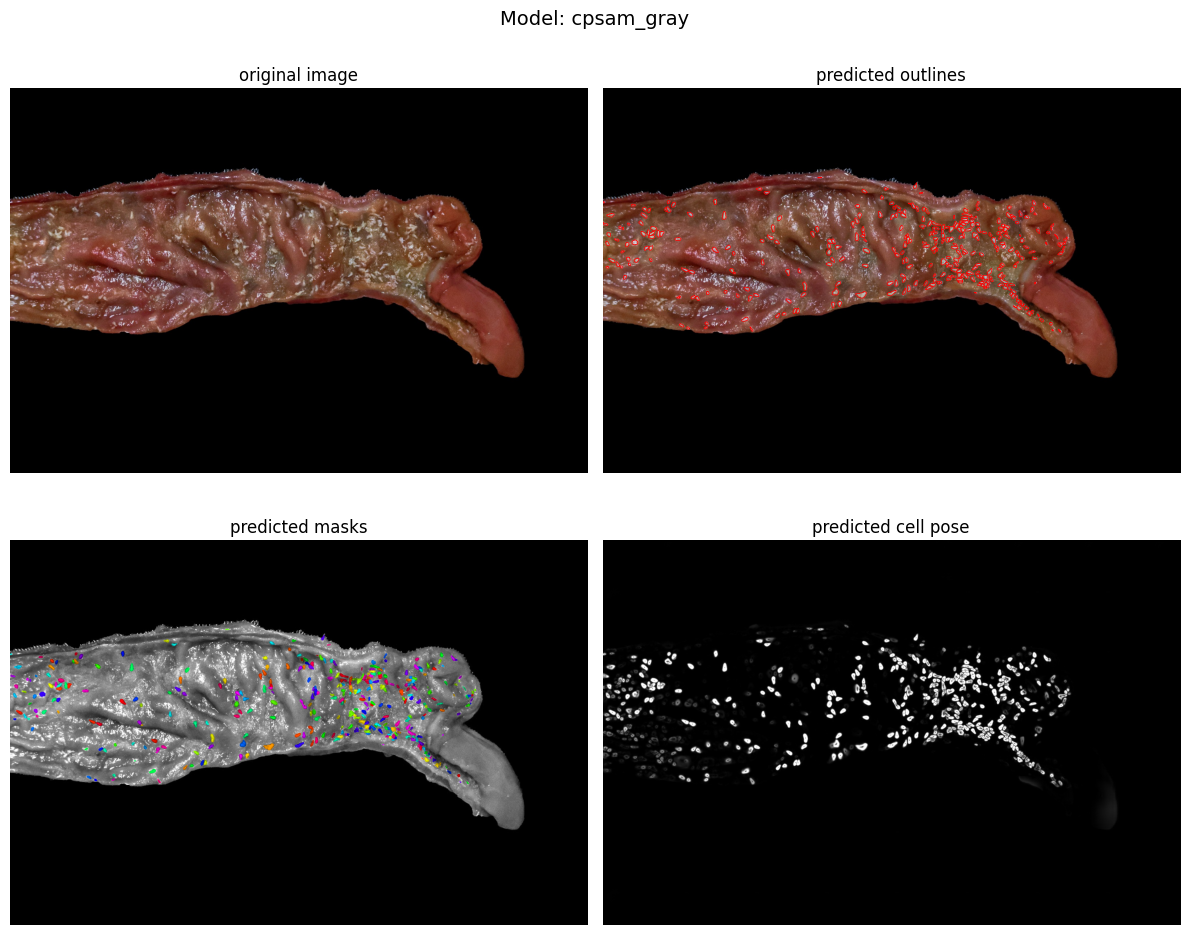

In [ ]:
# ---- Run cpsam strict in both modes ----
run_and_plot("cpsam", img, FLOW_TH, CELLPROB_TH, force_gray=True)  # RGB input


=== Running omni ===
2025-09-18 17:43:03,562 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:43:03,564 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:43:03,565 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:43:06,199 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:43:06,812 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
omni count: 306


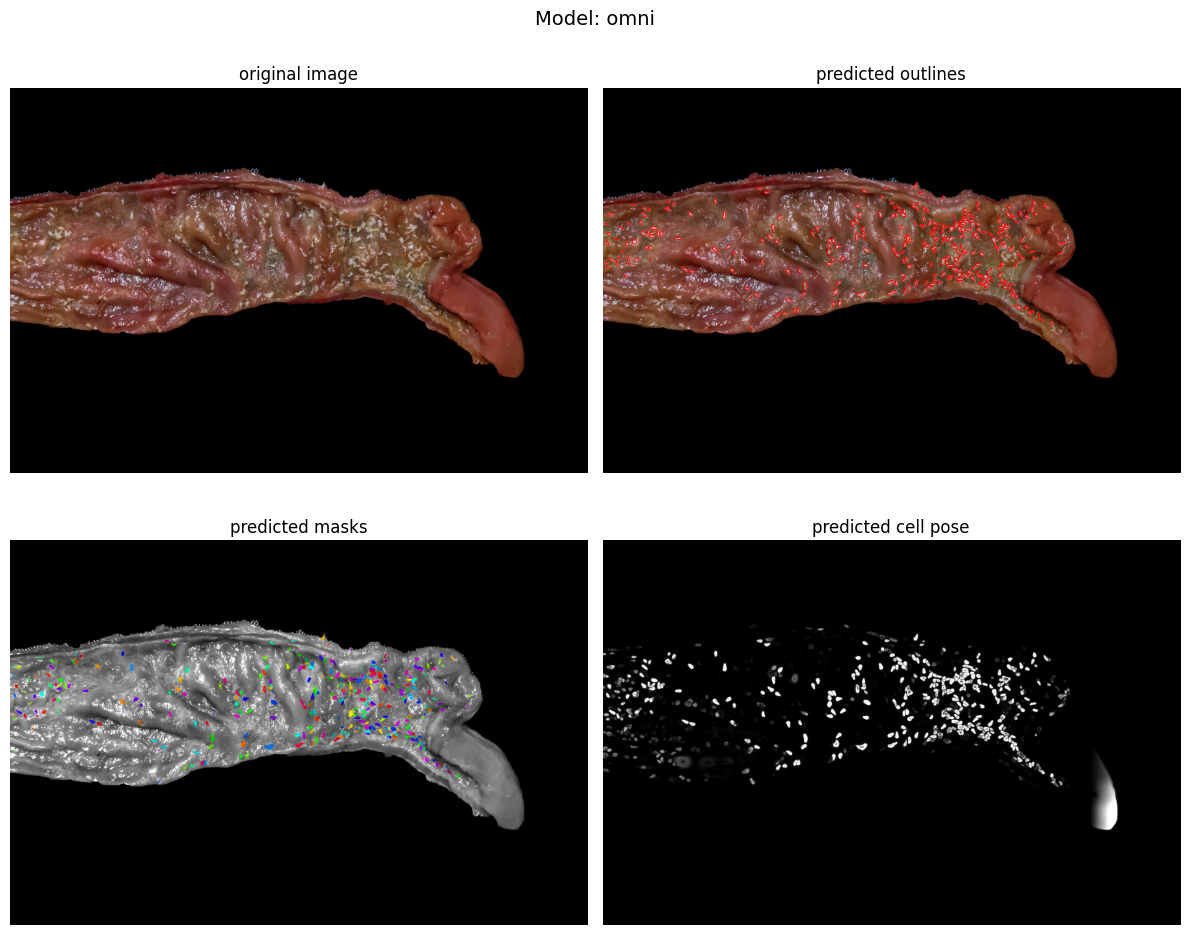

In [ ]:
# ---- Run omni strict ----
run_and_plot("omni", img, FLOW_TH, CELLPROB_TH)


=== Running omni_gray ===
2025-09-18 17:44:08,715 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:44:08,717 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:44:08,719 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:44:11,085 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:44:11,604 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
omni_gray count: 340


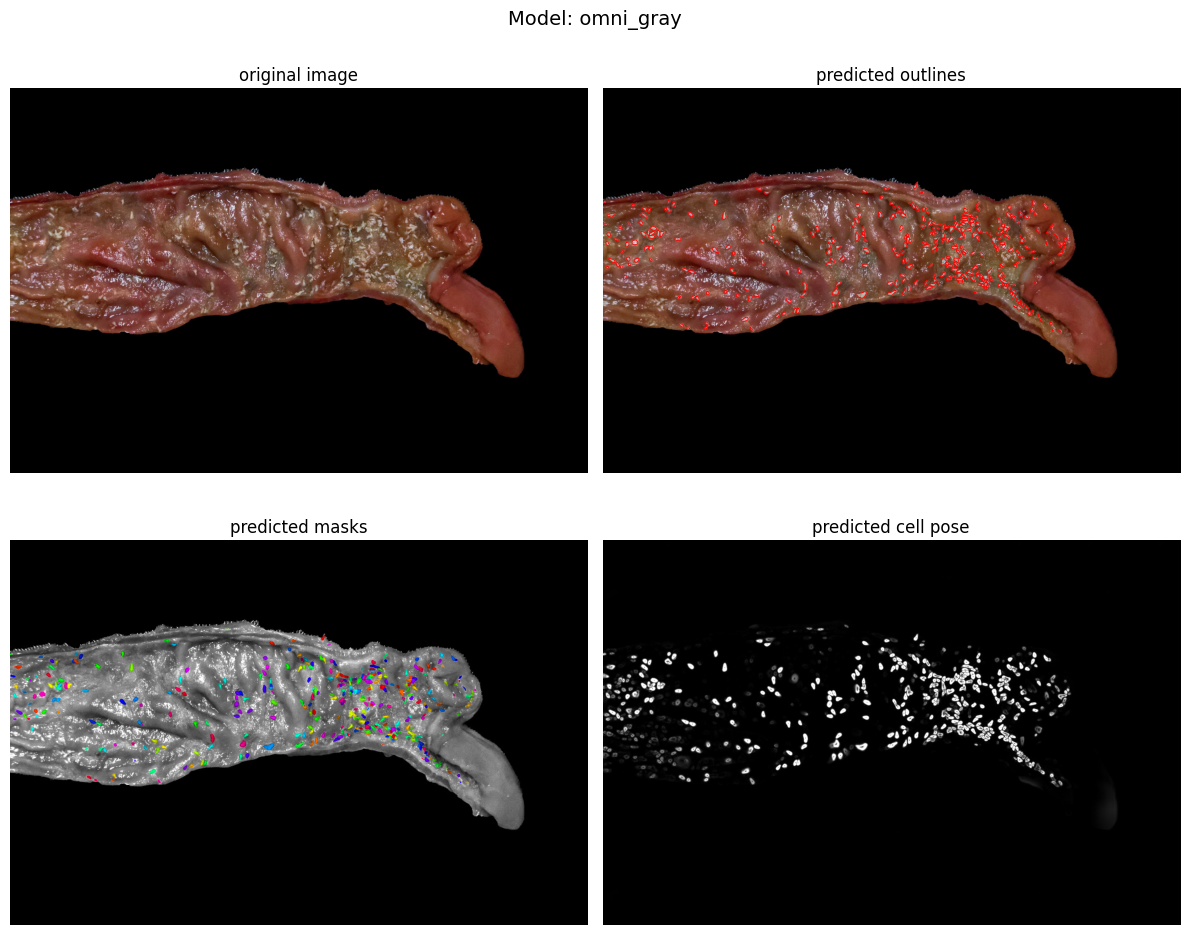

In [ ]:
# ---- Run omni strict ----
run_and_plot("omni", img, FLOW_TH, CELLPROB_TH,force_gray=True)


=== Running omni_gray ===
2025-09-18 17:55:28,610 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:55:28,612 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:55:28,613 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:55:30,855 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:55:31,634 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
omni_gray count: 290


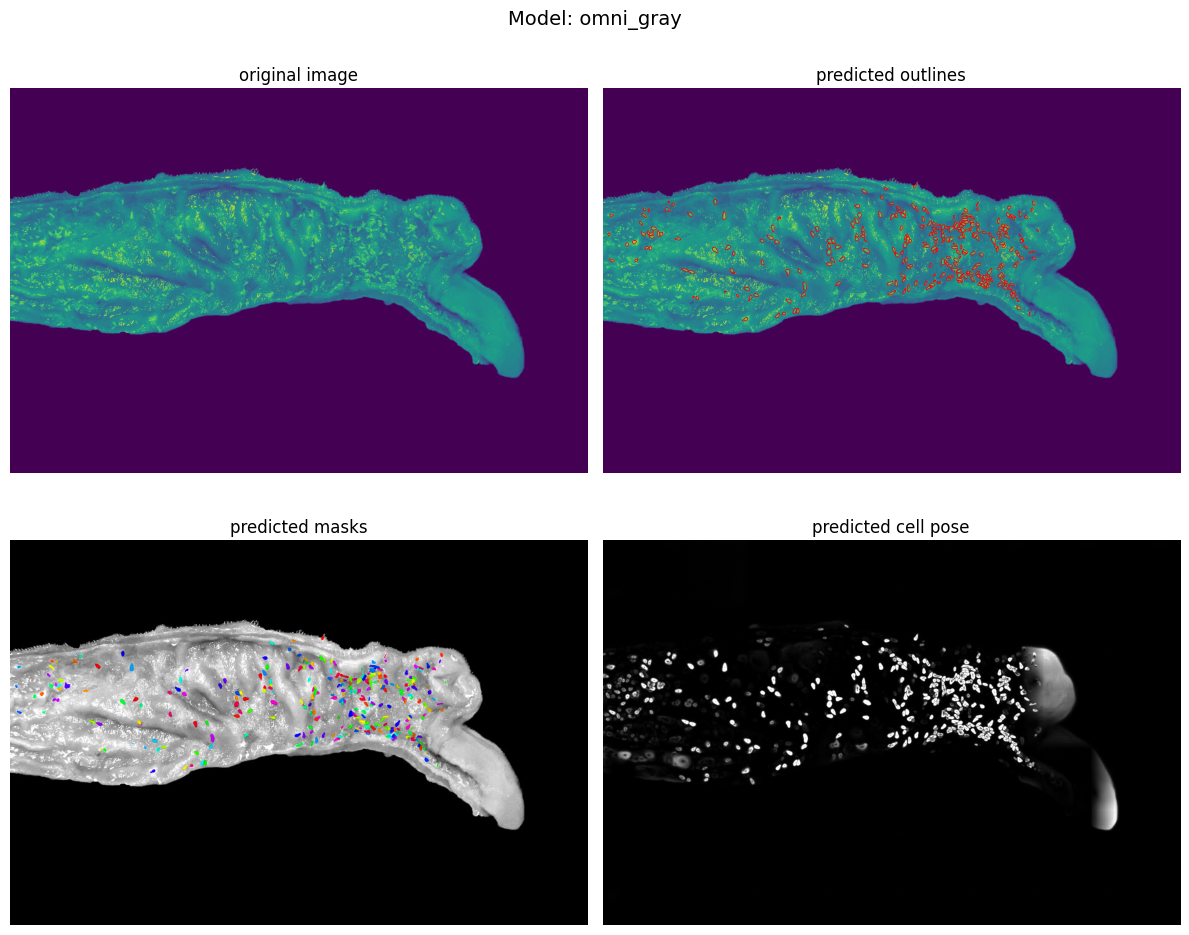

In [ ]:
red = img[...,0][...,None]
run_and_plot("omni", red, FLOW_TH, CELLPROB_TH, force_gray=True)



=== Running omni ===
2025-09-18 17:55:58,760 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:55:58,762 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:55:58,763 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:56:00,997 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:56:01,738 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
omni count: 365


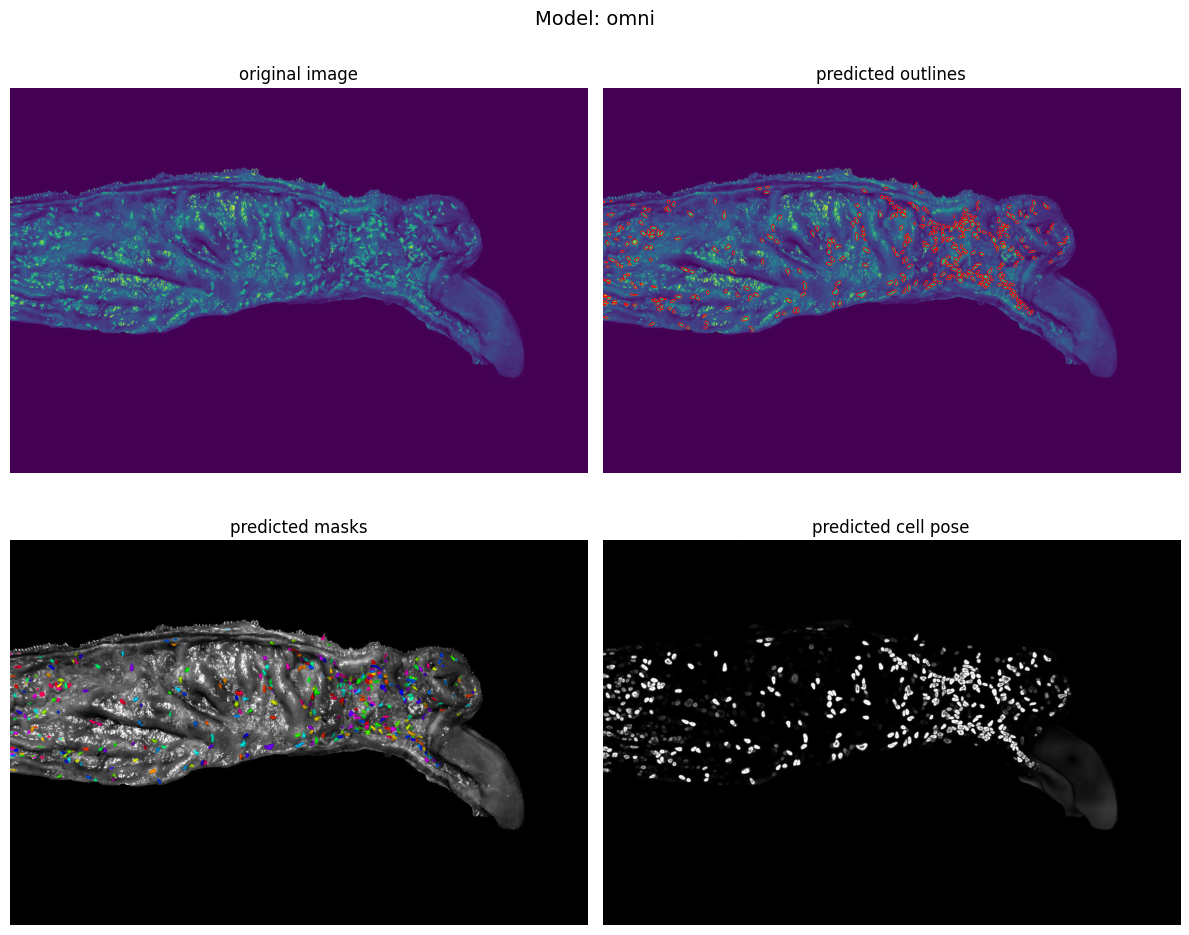

In [ ]:
blue = img[...,2][...,None]
run_and_plot("omni", blue, FLOW_TH, CELLPROB_TH, force_gray=False)



=== Running omni_gray ===
2025-09-18 17:56:46,998 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:56:47,000 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:56:47,003 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:56:49,306 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:56:50,167 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
omni_gray count: 365


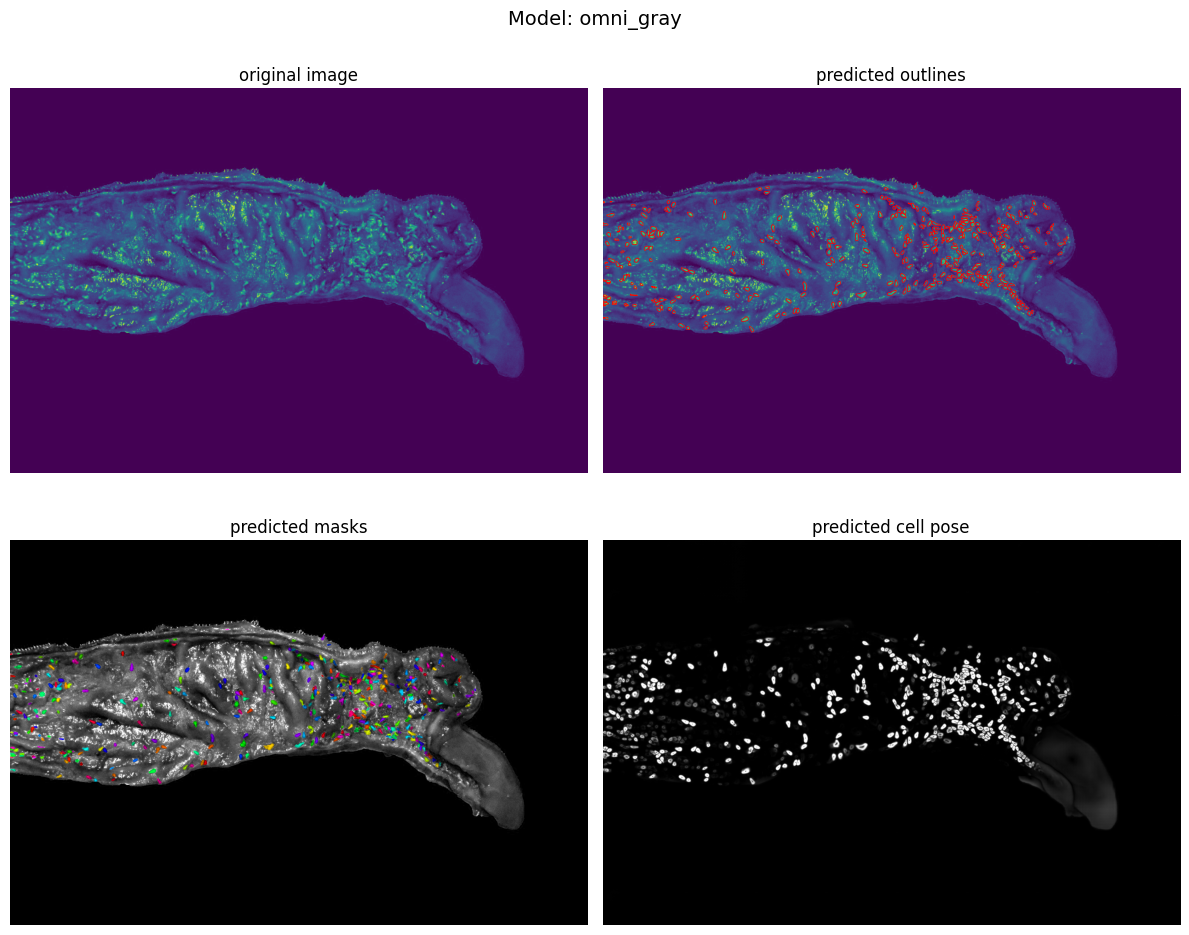

In [ ]:
blue = img[...,2][...,None]
run_and_plot("omni", blue, FLOW_TH, CELLPROB_TH, force_gray=True)



=== Running omni_gray ===
2025-09-18 17:54:11,998 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2025-09-18 17:54:12,000 [INFO] ** TORCH CUDA version installed and working. **
2025-09-18 17:54:12,000 [INFO] >>>> using GPU (CUDA)
2025-09-18 17:54:14,212 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-09-18 17:54:14,798 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
omni_gray count: 344


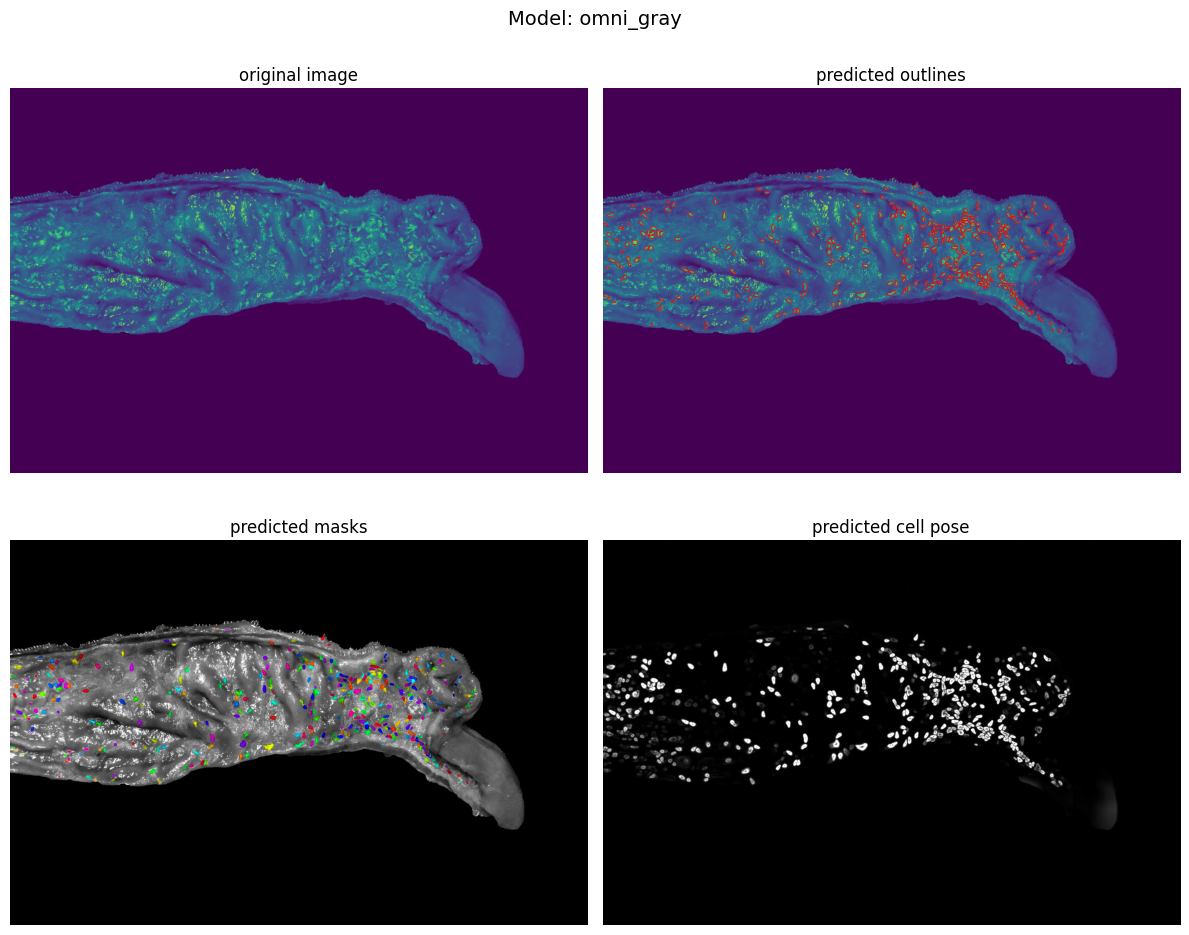

In [ ]:
green = img[...,1][...,None]
run_and_plot("omni", green, FLOW_TH, CELLPROB_TH, force_gray=True)
